In [1]:
!pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 3.8 MB/s eta 0:00:00a 0:00:01


In [2]:
import numpy as np 
import pandas as pd 
from kaggle_secrets import UserSecretsClient
import os
import shutil
import time
import json
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.decomposition import IncrementalPCA
import math
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.impute import KNNImputer
import prince
import zoneinfo

In [3]:
def get_dtime():
    moscow_tz = zoneinfo.ZoneInfo("Europe/Moscow")
    now = datetime.now(moscow_tz)
    return now.strftime("%d-%m-%H-%M-%S")

In [4]:
def frequency_encoding(df):
    """
    Применяет частотное кодирование ко всем колонкам DataFrame
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Исходный DataFrame
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame с частотно-закодированными колонками
    dict
        Словарь с частотами для каждой колонки
    """
    df_encoded = df.copy()
    frequency_maps = {}
    
    for column in df.columns:
        # Вычисляем частоты для каждой категории в колонке
        freq = df[column].value_counts(normalize=True)
        frequency_maps[column] = freq
        
        # Заменяем значения на их частоты
        df_encoded[column] = df[column].map(freq)
    
    return df_encoded, frequency_maps

In [5]:
def create_barplot(data, labels=None, title="Барплот", xlabel="Категории", 
                   ylabel="Значения", color="skyblue", figsize=(10, 6)):
    """
    Создает столбчатую диаграмму на основе входного массива.
    
    Параметры:
    data : array-like
        Массив значений для отображения
    labels : array-like, optional
        Метки для каждого столбца
    title : str
        Заголовок графика
    xlabel : str
        Подпись оси X
    ylabel : str
        Подпись оси Y
    color : str
        Цвет столбцов
    figsize : tuple
        Размер фигуры (ширина, высота)
    """
    plt.figure(figsize=figsize)
    
    # Если метки не предоставлены, создаем числовые метки
    if labels is None:
        labels = [f"Кат{i+1}" for i in range(len(data))]
    
    # Создание барплота
    plt.bar(labels, data, color=color, edgecolor="black", linewidth=1.5)
    
    # Настройка графика
    plt.title(title, fontsize=16, fontweight="bold")
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(axis="y", alpha=0.3, linestyle="--")
    
    # Поворот меток для лучшей читаемости
    #plt.xticks(rotation=45, ha="right")
    
    # Добавление значений над столбцами
    #for i, v in enumerate(data):
    #    plt.text(i, v + max(data)*0.01, str(v), ha="center", fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    
    return plt.gcf()


In [6]:
def plot_unique_value_distribution(df, max_unique_to_show=20, figsize=(12, 6)):
    """
    Подсчитывает количество колонок с 1, 2, 3 и т.д. уникальными значениями
    и строит barplot
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Исходный датафрейм
    max_unique_to_show : int
        Максимальное количество уникальных значений для отображения
    figsize : tuple
        Размер графика
    """
    
    # Подсчет уникальных значений в каждой колонке
    unique_counts = df.nunique()
    
    # Подсчет количества колонок для каждого значения уникальности
    value_counts = unique_counts.value_counts().sort_index()
    
    # Ограничиваем количество отображаемых значений
    if len(value_counts) > max_unique_to_show:
        print(f"Предупреждение: слишком много значений ({len(value_counts)}), показываем топ-{max_unique_to_show}")
        # Берем первые max_unique_to_show и суммируем остальные
        value_counts_to_show = value_counts.iloc[:max_unique_to_show].copy()
        other_sum = value_counts.iloc[max_unique_to_show:].sum()
        if other_sum > 0:
            value_counts_to_show['Другие'] = other_sum
    else:
        value_counts_to_show = value_counts
    
    # Построение графика
    plt.figure(figsize=figsize)
    
    bars = plt.bar(range(len(value_counts_to_show)), value_counts_to_show.values, 
                   color='steelblue', edgecolor='navy', alpha=0.7)
    
    # Добавление значений над столбцами
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                str(int(height)), ha='center', va='bottom', fontsize=10)
    
    # Настройка подписей
    plt.xticks(range(len(value_counts_to_show)), 
               [str(idx) for idx in value_counts_to_show.index], 
               rotation=45, ha='right')
    
    plt.xlabel('Количество уникальных значений в колонке', fontsize=12)
    plt.ylabel('Количество колонок', fontsize=12)
    plt.title('Распределение колонок по количеству уникальных значений', 
              fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    
    # Добавление аннотации с общей статистикой
    total_cols = len(df.columns)
    textstr = f'Всего колонок: {total_cols}\n'
    textstr += f'Среднее уникальных: {unique_counts.mean():.1f}\n'
    textstr += f'Медиана уникальных: {unique_counts.median():.0f}'
    plt.text(0.98, 0.98, textstr, transform=plt.gca().transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

In [7]:
def plot_histogram(data, bin_width=None, bins='auto', title='Гистограмма', 
                   xlabel='Значения', ylabel='Частота', figsize=(10, 6)):
    
    plt.figure(figsize=figsize)
    
    # Если указана ширина бина, рассчитываем количество бинов
    if bin_width is not None:
        data_range = np.max(data) - np.min(data)
        bins = int(np.ceil(data_range / bin_width))
    
    # Построение гистограммы
    plt.hist(data, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
    
    # Настройка графика
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
def plot_correlation_matrix(df, figsize=(12, 10), cmap='coolwarm', 
                           annot=False, fmt='.2f', title='Correlation Matrix'):

    
    # Выбираем только числовые колонки
    numeric_df = df.select_dtypes(include=[np.number])
    
    if len(numeric_df.columns) < 2:
        print("Ошибка: нужно как минимум 2 числовых признака")
        return None
    
    # Расчет матрицы корреляций
    corr_matrix = numeric_df.corr()
    
    # Построение тепловой карты
    plt.figure(figsize=figsize)
    
    # Маска для верхнего треугольника
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=annot, 
                fmt=fmt, 
                cmap=cmap,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8, 'label': 'Correlation'},
                vmin=-1, vmax=1,
                annot_kws={'size': 8})
    
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    #plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.xticks([])
    plt.yticks([])
    #plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()
    
    return corr_matrix

# Hyperparameters

In [281]:
threshold = 0.8 # max na_ratio in column that we can allow (drop otherwise)
pca_min_cum_var = 0.95
fillna_strategy = 'mean' # zero or mean 
cat_processing = "ohe" # ohe or mca

# DON'T SET TO (1,x,y) where x+y>=1
do_pca = True
add_na_mask = False
add_outlier_mask = False

do_scale = True

In [282]:
root = "/kaggle/input/datasets/lolikion228/some-serious-shit/data/"

In [283]:
train_main_feats = pd.read_parquet(root + "train_main_features.parquet")
train_target = pd.read_parquet(root + "train_target.parquet")

# Train data preprocessing

In [284]:
Y = train_target.iloc[:,1:]
Y

,target_1_1,target_1_2,target_1_3,target_1_4,target_1_5,target_2_1,target_2_2,target_2_3,target_2_4,target_2_5,...,target_8_3,target_9_1,target_9_2,target_9_3,target_9_4,target_9_5,target_9_6,target_9_7,target_9_8,target_10_1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
749996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
749997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
749998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [285]:
Y[Y["target_9_6"]==1]

,target_1_1,target_1_2,target_1_3,target_1_4,target_1_5,target_2_1,target_2_2,target_2_3,target_2_4,target_2_5,...,target_8_3,target_9_1,target_9_2,target_9_3,target_9_4,target_9_5,target_9_6,target_9_7,target_9_8,target_10_1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
749977,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
749987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
749992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [286]:
cat_feats = train_main_feats.filter(like="cat")
num_feats = train_main_feats.filter(like="num")

# Numerical features

In [287]:
print(num_feats.shape)

(750000, 132)


# NA's

In [288]:
na_mask = num_feats.isna()
na_ratio = na_mask.mean(axis=0)

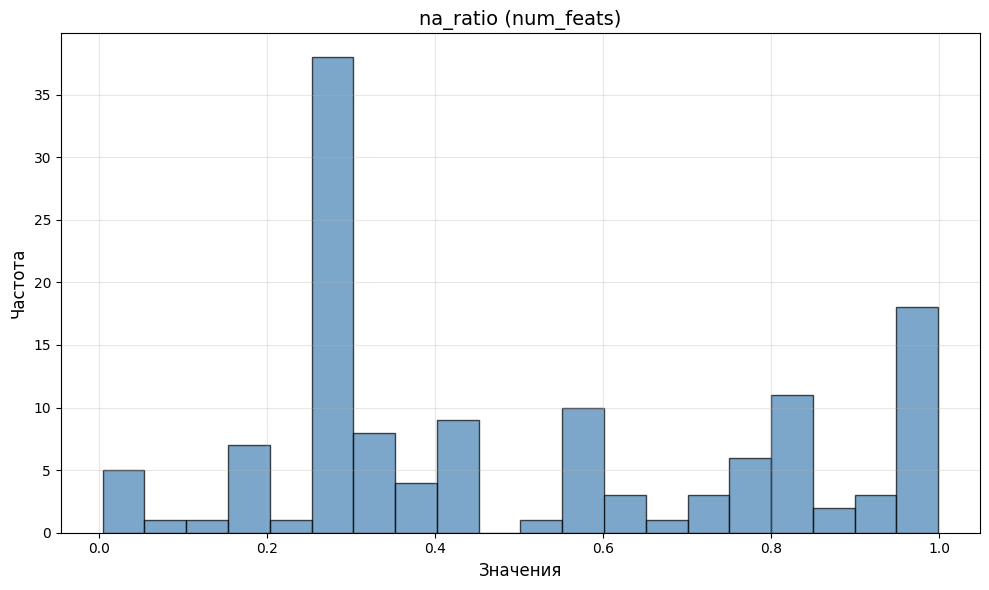

In [289]:
plot_histogram(na_ratio, bin_width=0.05, title="na_ratio (num_feats)")

In [290]:
na_ratio = num_feats.isna().mean()
cols_to_keep = na_ratio[na_ratio <= threshold].index.tolist()
num_feats = num_feats.filter(items=cols_to_keep)
na_mask = na_mask.filter(items=cols_to_keep)

# Outliers

In [291]:
q1 = num_feats.quantile(q=0.25)
q3 = num_feats.quantile(q=0.75)
iqr = q3 - q1
outlier_mask = (num_feats < q1 - iqr * 1.5) | (num_feats > q3 + iqr * 1.5) # false on NA's
outliers_by_col = outlier_mask.sum(axis=0)

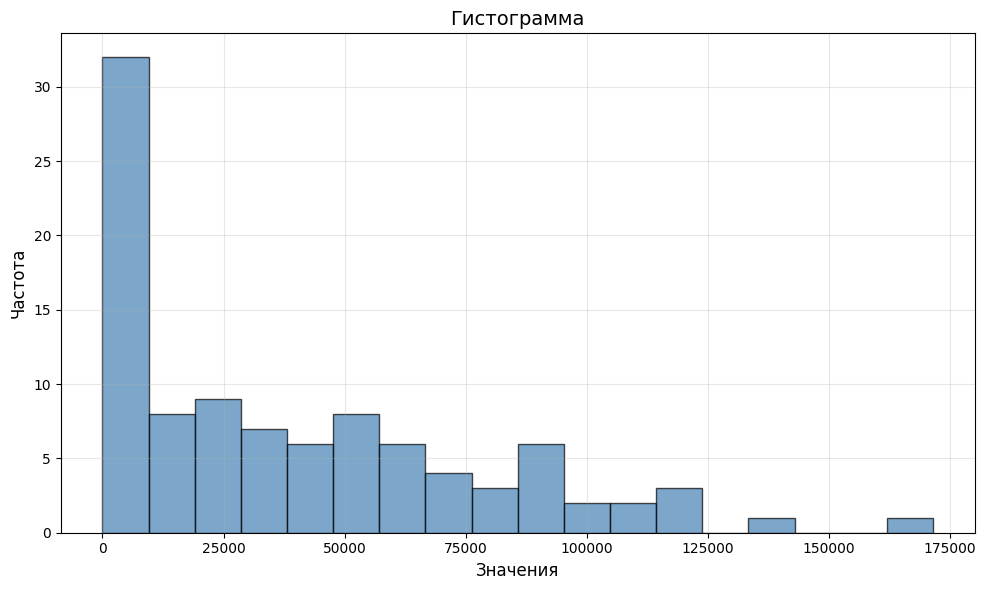

In [292]:
plot_histogram(outliers_by_col, bin_width=10_000)

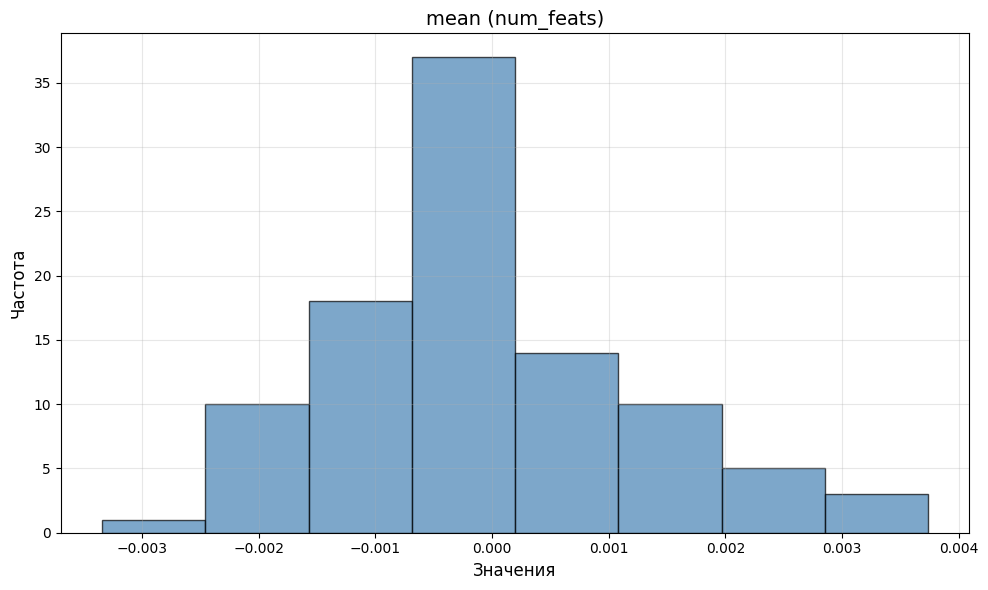

In [293]:
mean = num_feats.mean(axis=0)
plot_histogram(mean, bin_width=0.001, title="mean (num_feats)")

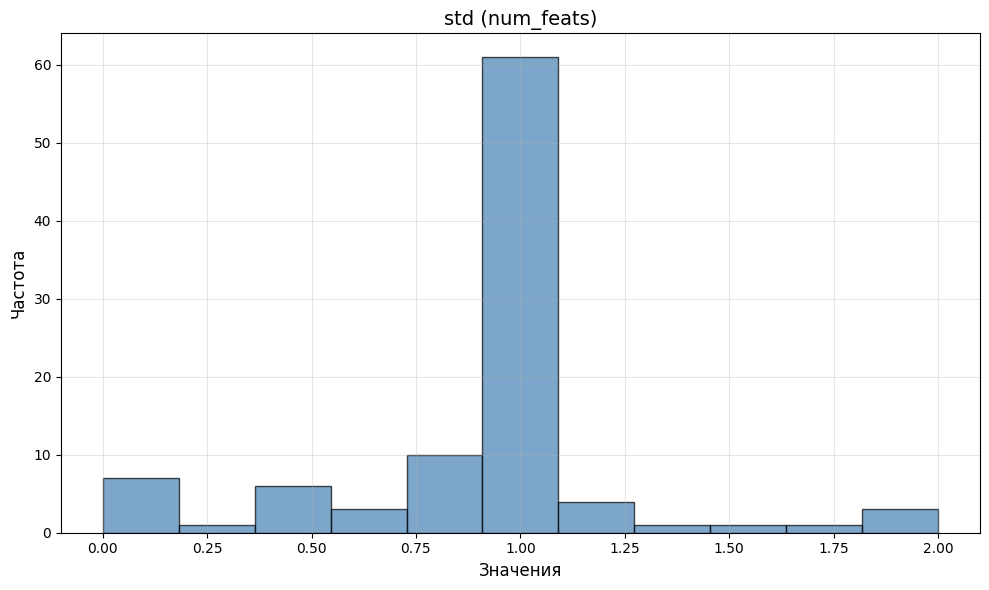

In [294]:
std = num_feats.std(axis=0)
plot_histogram(std, bin_width=0.2, title="std (num_feats)")

In [295]:
z = std[std<=1e-3]
small_std_ix = z.index.to_list()
print(z)
print()
print(na_ratio[small_std_ix])

num_feature_9      0.0
num_feature_14     0.0
num_feature_32     0.0
num_feature_80     0.0
num_feature_106    0.0
dtype: float64

num_feature_9      0.297049
num_feature_14     0.297049
num_feature_32     0.297049
num_feature_80     0.297049
num_feature_106    0.297049
dtype: float64


In [296]:
num_feats = num_feats.drop(small_std_ix, axis=1)
na_mask = na_mask.drop(small_std_ix, axis=1)
outlier_mask = outlier_mask.drop(small_std_ix, axis=1)

In [297]:
if fillna_strategy == 'mean':
    old_mean = num_feats.mean()
    num_feats_cleaned = num_feats.fillna(old_mean)
elif fillna_strategy == 'zero':
    num_feats_cleaned = num_feats.fillna(0)
else:
    raise Exception("invalid")
    
num_feats_cleaned.isna().sum().sum()

np.int64(0)

In [298]:
if do_scale:
    scaler = StandardScaler()
    num_feats_cleaned = scaler.fit_transform(num_feats_cleaned)

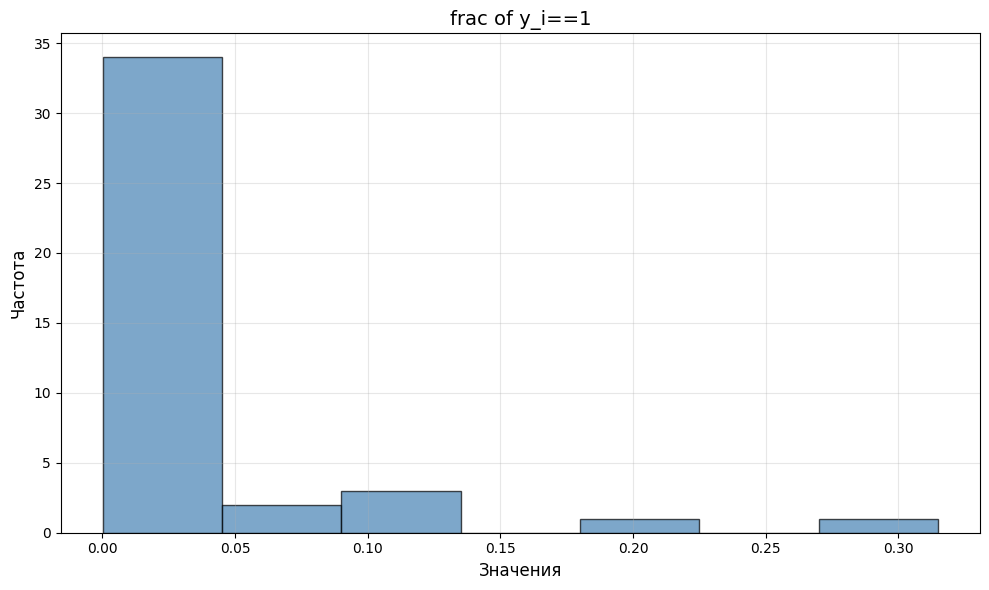

In [299]:
Z = Y.mean(axis=0)
plot_histogram(Z, bin_width=0.05, title="frac of y_i==1")

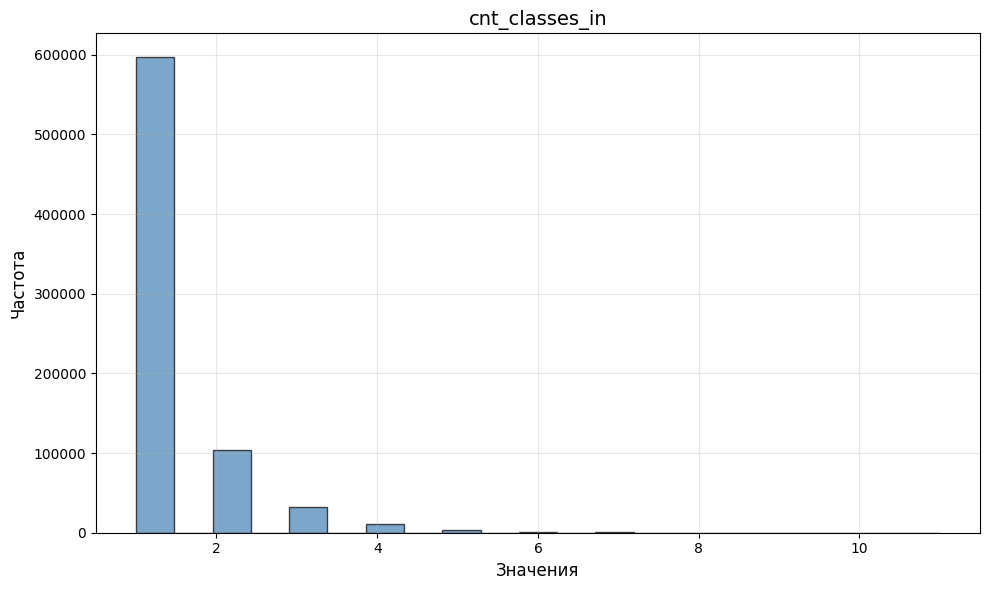

In [300]:
Z = Y.sum(axis=1)
plot_histogram(Z, title="cnt_classes_in")

In [301]:
num_feats_cleaned.shape

(750000, 93)

In [302]:
if do_pca:
    ipca = IncrementalPCA()
    ipca.fit(num_feats_cleaned)
    cum_var = np.cumsum(ipca.explained_variance_ratio_)
    pca_n_comp = np.where(cum_var > pca_min_cum_var)[0].min()
    pca_n_comp

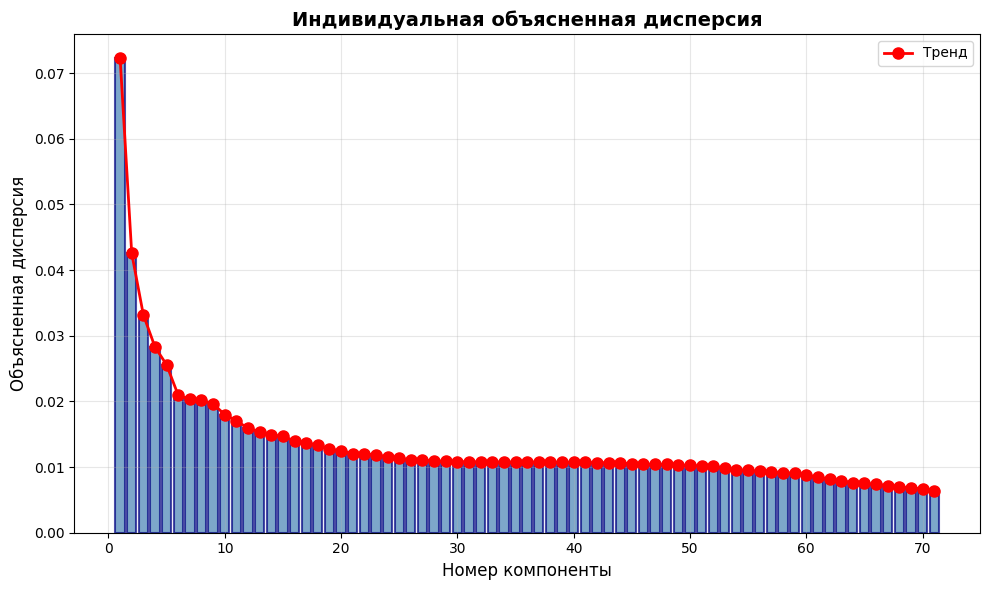

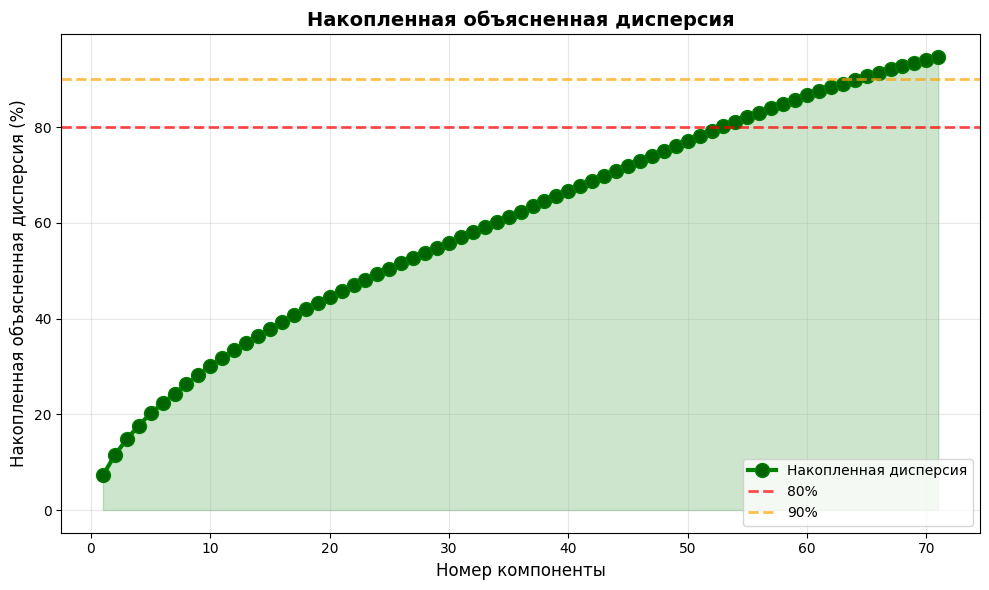

In [303]:
if do_pca:
    explained_variance = ipca.explained_variance_ratio_[:pca_n_comp]
    cumulative_variance = np.cumsum(explained_variance)
    components = np.arange(1, len(explained_variance) + 1)
    
    # ГРАФИК 1: Индивидуальная объясненная дисперсия
    plt.figure(figsize=(10, 6))
    bars = plt.bar(components, explained_variance, alpha=0.7, 
                   color='steelblue', edgecolor='navy', linewidth=1.5)
    plt.plot(components, explained_variance, 'ro-', linewidth=2, markersize=8, 
             label='Тренд', markerfacecolor='red')
    
    
    plt.xlabel('Номер компоненты', fontsize=12)
    plt.ylabel('Объясненная дисперсия', fontsize=12)
    plt.title('Индивидуальная объясненная дисперсия', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    #plt.xticks(components)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # ГРАФИК 2: Накопленная объясненная дисперсия
    plt.figure(figsize=(10, 6))
    plt.plot(components, cumulative_variance * 100, 'go-', linewidth=3, 
             markersize=10, label='Накопленная дисперсия', markerfacecolor='darkgreen')
    plt.fill_between(components, 0, cumulative_variance * 100, 
                     alpha=0.2, color='green')
    
    # Добавление пороговых линий
    plt.axhline(y=80, color='red', linestyle='--', linewidth=2, alpha=0.7, label='80%')
    plt.axhline(y=90, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='90%')
    
    
    plt.xlabel('Номер компоненты', fontsize=12)
    plt.ylabel('Накопленная объясненная дисперсия (%)', fontsize=12)
    plt.title('Накопленная объясненная дисперсия', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    #plt.xticks(components)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

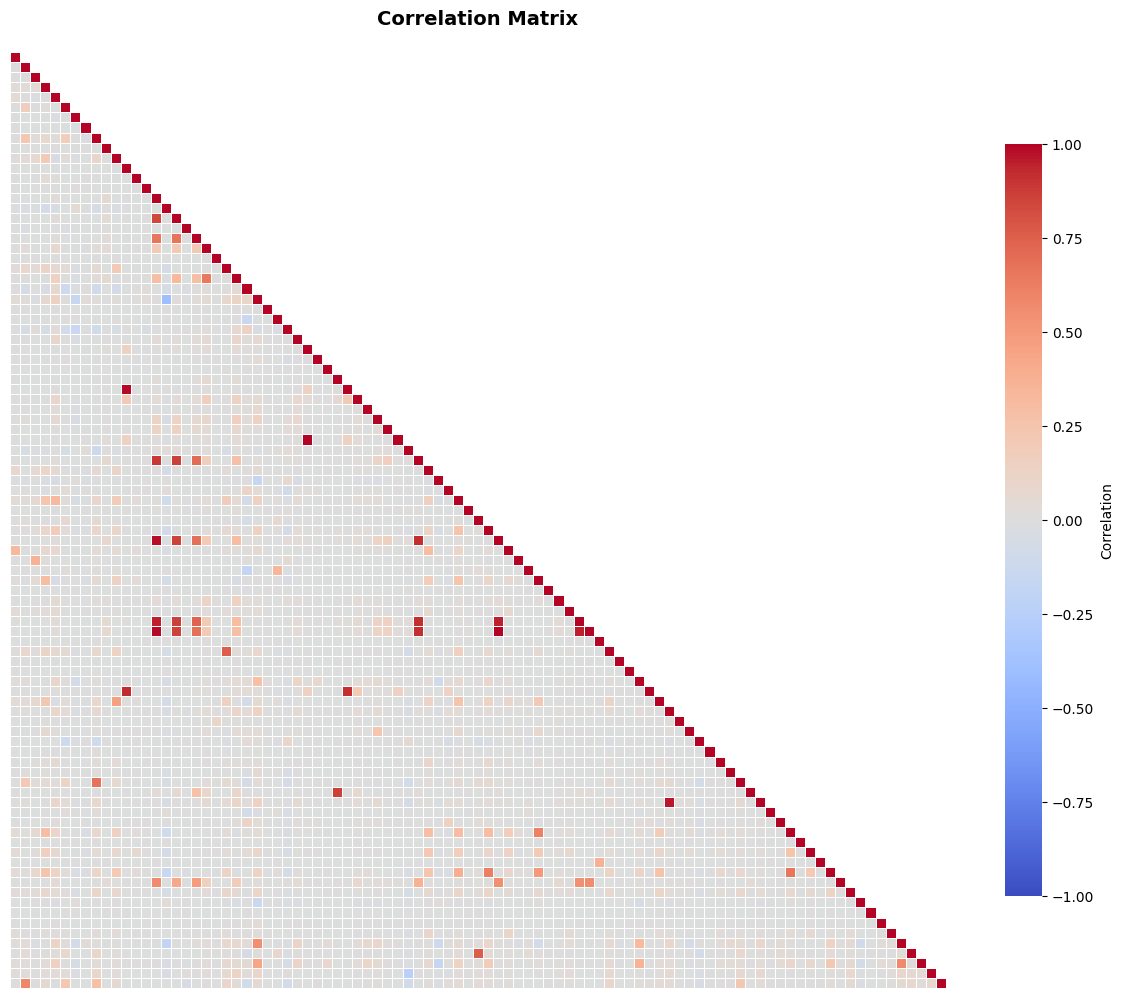

In [304]:
сorr_mat = plot_correlation_matrix(pd.DataFrame(num_feats_cleaned))

In [305]:
if do_pca:
    num_encoded = ipca.transform(num_feats_cleaned)[:,:pca_n_comp]
    
else:
    num_encoded = num_feats_cleaned
    
    if add_na_mask:
        num_encoded = np.concatenate([num_encoded, na_mask], axis=1)
        
    if add_outlier_mask:
        num_encoded = np.concatenate([num_encoded, outlier_mask], axis=1)

In [306]:
num_encoded.shape

(750000, 71)

# Categorical features

In [307]:
print(cat_feats.shape)

(750000, 67)


In [308]:
cat_feats.isna().sum().sum()

np.int64(0)

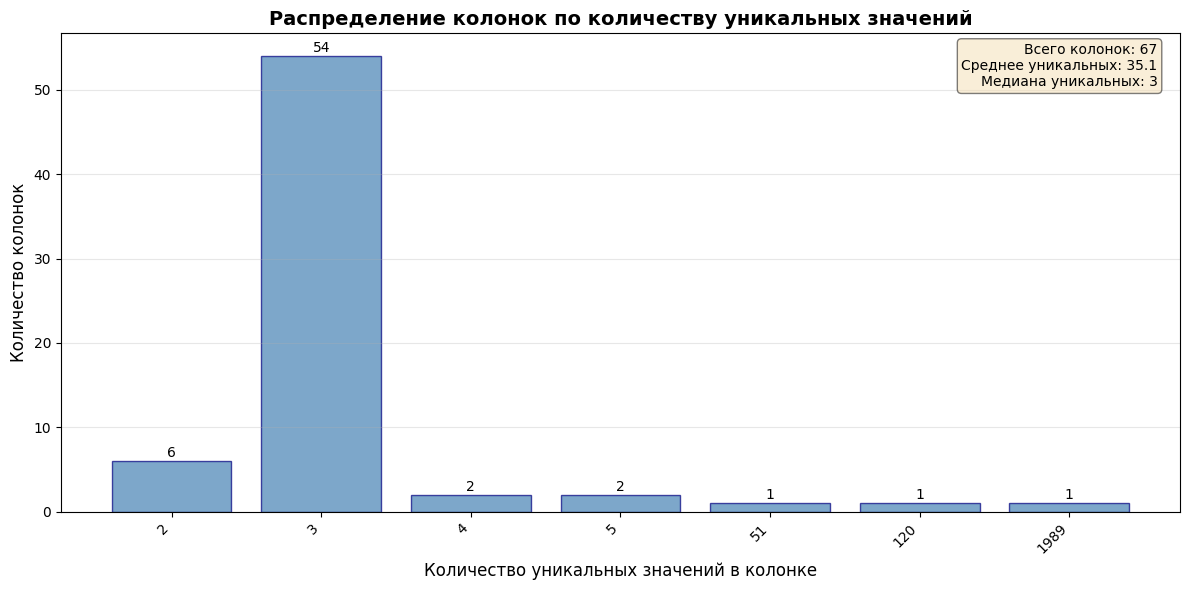

In [309]:
plot_unique_value_distribution(cat_feats)

In [310]:
cols_to_keep_cat = [col for col in cat_feats.columns if cat_feats[col].nunique() <= 6]
cat_feats_filtered = cat_feats[cols_to_keep_cat]

In [311]:
cat_feats_filtered.shape

(750000, 64)

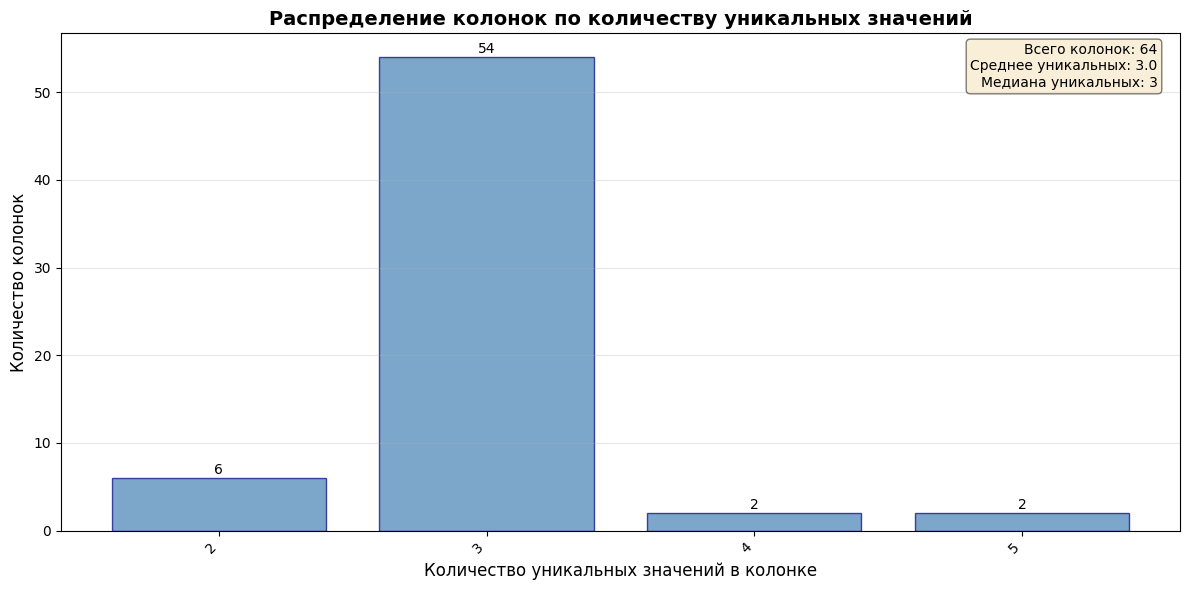

In [312]:
plot_unique_value_distribution(cat_feats_filtered)

In [313]:
big_cols = [col for col in cat_feats.columns if col not in cols_to_keep_cat]
big_cols

['cat_feature_34', 'cat_feature_39', 'cat_feature_52']

In [314]:
cat_feats['cat_feature_34'].value_counts()

cat_feature_34
212.0    744306
0.0         792
1.0         719
2.0         616
3.0         323
          ...  
170.0         1
80.0          1
76.0          1
139.0         1
78.0          1
Name: count, Length: 120, dtype: int64

In [315]:
cat_feats['cat_feature_39'].value_counts()

cat_feature_39
2141.0    585646
0.0         1965
1.0         1000
2.0          845
3.0          693
           ...  
1995.0         1
1884.0         1
1981.0         1
1910.0         1
1917.0         1
Name: count, Length: 1989, dtype: int64

In [316]:
cat_feats['cat_feature_52'].value_counts()

cat_feature_52
50.0    288487
0.0      89833
1.0      39333
2.0      37601
3.0      34956
4.0      32108
5.0      27035
6.0      26606
7.0      21705
8.0      17311
9.0      14737
10.0     13497
11.0     12898
12.0     11028
13.0     10195
14.0      5990
15.0      4530
17.0      3698
16.0      3657
18.0      3474
19.0      3397
20.0      3192
21.0      3046
22.0      3039
23.0      2935
24.0      2867
25.0      2773
26.0      2692
27.0      2518
28.0      2256
30.0      2172
31.0      2171
29.0      2150
32.0      2125
36.0      2002
33.0      1973
34.0      1971
35.0      1922
37.0      1679
38.0       907
39.0       856
40.0       623
41.0       455
42.0       428
44.0       258
43.0       256
45.0       203
46.0       160
47.0       154
48.0       121
49.0        20
Name: count, dtype: int64

In [317]:
cat_processing

'ohe'

In [318]:
if cat_processing == "ohe":
    small_cat_encoded = pd.get_dummies(
            cat_feats[cols_to_keep_cat], 
            columns=cols_to_keep_cat,
            drop_first=True,
            dtype=float
            )
    
elif cat_processing == "mca":
    mca = prince.MCA(
        n_components = 8,
        n_iter=16,
        copy=True,
        check_input=True,
        engine='sklearn',
        random_state=42,
        correction='benzecri'
    )
    mca = mca.fit(cat_feats_filtered)
    small_cat_encoded = mca.transform(cat_feats_filtered)
    print(mca.eigenvalues_summary)
    
else:
    raise Exception("invalid")

In [319]:
small_cat_encoded

,cat_feature_1_1.0,cat_feature_2_1.0,cat_feature_2_2.0,cat_feature_3_1.0,cat_feature_3_2.0,cat_feature_4_1.0,cat_feature_5_1.0,cat_feature_5_2.0,cat_feature_6_1.0,cat_feature_6_2.0,...,cat_feature_63_1.0,cat_feature_63_2.0,cat_feature_64_1.0,cat_feature_64_2.0,cat_feature_65_1.0,cat_feature_65_2.0,cat_feature_66_1.0,cat_feature_66_2.0,cat_feature_67_1.0,cat_feature_67_2.0
0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
749996,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
749997,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
749998,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [320]:
big_cat_encoded, frequency_maps = frequency_encoding(cat_feats[big_cols])

In [321]:
cat_encoded = pd.concat([big_cat_encoded, small_cat_encoded],axis=1)
cat_encoded

,cat_feature_34,cat_feature_39,cat_feature_52,cat_feature_1_1.0,cat_feature_2_1.0,cat_feature_2_2.0,cat_feature_3_1.0,cat_feature_3_2.0,cat_feature_4_1.0,cat_feature_5_1.0,...,cat_feature_63_1.0,cat_feature_63_2.0,cat_feature_64_1.0,cat_feature_64_2.0,cat_feature_65_1.0,cat_feature_65_2.0,cat_feature_66_1.0,cat_feature_66_2.0,cat_feature_67_1.0,cat_feature_67_2.0
0,0.992408,0.780861,0.002563,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.992408,0.780861,0.003589,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.992408,0.780861,0.035475,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.992408,0.000085,0.036047,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.992408,0.780861,0.384649,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,0.992408,0.780861,0.017197,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
749996,0.992408,0.780861,0.052444,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
749997,0.992408,0.780861,0.384649,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
749998,0.992408,0.000093,0.119777,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [322]:
X = np.concatenate([cat_encoded, num_encoded], axis=1)
X.shape

(750000, 202)

In [323]:
X = pd.DataFrame(X).astype('float32')

# Test data preprocessing

In [324]:
test_df = pd.read_parquet(root + "test_main_features.parquet")

In [325]:
test_num_feats = test_df.filter(like="num")
test_cat_feats = test_df.filter(like="cat")

# Categorical

In [326]:
print(big_cols)

['cat_feature_34', 'cat_feature_39', 'cat_feature_52']


In [327]:
df_test_filled = test_cat_feats.copy()

for col in cat_feats.columns:
    valid_values = set(cat_feats[col].unique())
    
    mode_value = cat_feats[col].mode()[0]
    
    mask_new_values = ~test_cat_feats[col].isin(valid_values)

    df_test_filled.loc[mask_new_values, col] = mode_value

In [328]:
test_big_cat_encoded = df_test_filled.loc[:,big_cols]
for col in big_cols:
    test_big_cat_encoded[col] = test_big_cat_encoded.loc[:,col].map(lambda x: frequency_maps[col][x])

In [329]:
test_cat_feats_filtered = df_test_filled[cols_to_keep_cat]

In [330]:
if cat_processing == "ohe":
    test_small_cat_encoded = pd.get_dummies(
            test_cat_feats_filtered, 
            columns=cols_to_keep_cat,
            drop_first=True,
            dtype=float
            )
    
elif cat_processing == "mca":
    test_small_cat_encoded = mca.transform(test_cat_feats_filtered)
    
else:
    raise Exception

In [331]:
test_cat_encoded = pd.concat([test_big_cat_encoded, test_small_cat_encoded],axis=1)
test_cat_encoded

,cat_feature_34,cat_feature_39,cat_feature_52,cat_feature_1_1.0,cat_feature_2_1.0,cat_feature_2_2.0,cat_feature_3_1.0,cat_feature_3_2.0,cat_feature_4_1.0,cat_feature_5_1.0,...,cat_feature_63_1.0,cat_feature_63_2.0,cat_feature_64_1.0,cat_feature_64_2.0,cat_feature_65_1.0,cat_feature_65_2.0,cat_feature_66_1.0,cat_feature_66_2.0,cat_feature_67_1.0,cat_feature_67_2.0
0,0.992408,0.780861,0.119777,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.992408,0.780861,0.119777,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
2,0.992408,0.780861,0.002631,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.992408,0.780861,0.042811,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.992408,0.780861,0.013593,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,0.992408,0.780861,0.384649,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
249996,0.992408,0.780861,0.384649,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
249997,0.992408,0.780861,0.384649,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
249998,0.992408,0.780861,0.046608,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


# Numerical

In [332]:
test_num_feats_cleaned = test_num_feats.filter(items=cols_to_keep)
test_na_mask = test_num_feats_cleaned.isna()
test_outlier_mask = (test_num_feats_cleaned < q1 - iqr * 1.5) | (test_num_feats_cleaned > q3 + iqr * 1.5) 

In [333]:
test_num_feats_cleaned = test_num_feats_cleaned.drop(small_std_ix, axis=1)
test_na_mask = test_na_mask.drop(small_std_ix, axis=1)
test_outlier_mask = test_outlier_mask.drop(small_std_ix, axis=1)

In [334]:
if fillna_strategy == 'mean':
    test_num_feats_cleaned = test_num_feats_cleaned.fillna(old_mean)
elif fillna_strategy == 'zero':
    test_num_feats_cleaned = test_num_feats_cleaned.fillna(0)
else:
    raise Exception("invalid")
    
test_num_feats_cleaned.isna().sum().sum()

np.int64(0)

In [335]:
if do_scale:
    test_num_feats_cleaned = scaler.transform(test_num_feats_cleaned)

In [336]:
if do_pca:
    test_num_encoded = ipca.transform(test_num_feats_cleaned)[:,:pca_n_comp]
else:
    test_num_encoded = test_num_feats_cleaned
    
    if add_na_mask:
        test_num_encoded = np.concatenate([test_num_encoded, test_na_mask], axis=1)
        
    if add_outlier_mask:
        test_num_encoded = np.concatenate([test_num_encoded, test_outlier_mask], axis=1)

In [337]:
test_num_encoded.shape

(250000, 71)

In [338]:
X_test = np.concatenate([test_cat_encoded, test_num_encoded], axis=1)
X_test.shape

(250000, 202)

In [339]:
X_test = pd.DataFrame(X_test).astype('float32')

# Vibe Check

In [340]:
X

,0,1,2,3,4,5,6,7,8,9,...,192,193,194,195,196,197,198,199,200,201
0,0.992408,0.780861,0.002563,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.087296,-0.118596,0.068704,0.175733,-0.141561,0.057615,0.067604,0.009512,-0.034944,0.026832
1,0.992408,0.780861,0.003589,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.102049,-0.301139,-0.435962,1.597285,-0.835120,0.342721,0.016900,0.019838,0.069340,-0.319208
2,0.992408,0.780861,0.035475,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.431848,-1.063577,0.533315,0.349470,-0.312210,0.238122,0.233243,-0.005481,0.024529,-0.009681
3,0.992408,0.000085,0.036047,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.133670,0.022272,-0.060610,0.337668,0.193513,0.263965,-0.056025,0.005811,0.065078,0.008261
4,0.992408,0.780861,0.384649,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,-0.113351,-0.364791,0.277484,0.098533,-0.306205,-0.103779,0.138711,-0.003313,-0.001458,0.022378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,0.992408,0.780861,0.017197,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.191748,0.265591,-0.019234,0.852115,-0.407580,-0.219546,0.265437,0.005261,-0.025724,-0.075443
749996,0.992408,0.780861,0.052444,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,-0.447395,0.202264,0.244848,0.208387,0.053317,0.098387,0.119327,0.028462,-0.271181,-1.107395
749997,0.992408,0.780861,0.384649,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.195677,0.358248,-0.028910,-0.153512,0.387417,-0.001971,-0.123112,-0.013291,-0.056710,0.069740
749998,0.992408,0.000093,0.119777,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,-0.049888,0.332996,-0.448020,-0.293345,0.897384,0.281325,-0.428444,0.038820,-0.042868,-0.651044


In [341]:
X_test

,0,1,2,3,4,5,6,7,8,9,...,192,193,194,195,196,197,198,199,200,201
0,0.992408,0.780861,0.119777,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.727504,-0.638495,-0.295372,0.162082,0.604574,0.059698,-0.112863,-0.009893,0.088394,0.094657
1,0.992408,0.780861,0.119777,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.407004,-0.938723,-0.226263,0.266348,-0.120096,-0.033340,0.218423,-0.048279,0.279886,0.283825
2,0.992408,0.780861,0.002631,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,-0.171672,-0.272251,0.040919,-0.496275,0.722313,0.180638,-0.224314,-0.008302,0.004483,0.096221
3,0.992408,0.780861,0.042811,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-1.028292,0.781510,0.885551,-0.123812,0.909273,0.026779,-0.222677,0.031634,-0.225249,-1.807633
4,0.992408,0.780861,0.013593,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.467450,-0.132614,0.037536,-0.197822,-0.881081,-0.329422,0.200158,0.010721,-0.090357,0.139239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,0.992408,0.780861,0.384649,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.117599,0.217740,-0.008862,0.781229,-0.658003,0.068774,0.265637,0.006171,0.022237,-0.088338
249996,0.992408,0.780861,0.384649,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,-0.254546,-0.316658,0.232692,-0.094938,-0.096405,-0.014275,0.083341,-0.016612,-0.004165,0.094348
249997,0.992408,0.780861,0.384649,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,-0.105553,-0.218619,0.044026,-0.615333,0.555535,-0.070681,-0.184904,-0.009089,-0.041024,0.071564
249998,0.992408,0.780861,0.046608,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,-0.203980,-0.172789,0.309001,0.522732,-0.049284,0.272402,0.145048,-0.013624,-0.034820,0.037396


# Dataset creation

In [342]:
description = f"""
na_threshold = {threshold}\n
pca_min_cum_var = {pca_min_cum_var}\n
fillna_strategy = {fillna_strategy}\n
cat_processing = {cat_processing}\n
do_pca = {do_pca}\n
add_na_mask = {add_na_mask}\n
add_outlier_mask = {add_outlier_mask}\n
do_scale = {do_scale}
"""

In [343]:
print(description)


na_threshold = 0.8

pca_min_cum_var = 0.95

fillna_strategy = mean

cat_processing = ohe

do_pca = True

add_na_mask = False

add_outlier_mask = False

do_scale = True



In [344]:
KAGGLE_USERNAME = "Lolikion228"  
DATASET_NAME = f"hack-main-feats-{get_dtime()}"
DATASET_FOLDER = "/kaggle/working/my_dataset"
DATA_SUBFOLDER = "data"
FULL_DATA_PATH = os.path.join(DATASET_FOLDER, DATA_SUBFOLDER)

if os.path.exists(DATASET_FOLDER):
    shutil.rmtree(DATASET_FOLDER)
os.makedirs(FULL_DATA_PATH)

metadata = {
    "title": DATASET_NAME,  
    "id": f"{KAGGLE_USERNAME}/{DATASET_NAME}",  
    "licenses": [{"name": "CC0-1.0"}],
    "description": description,
}

metadata_path = os.path.join(DATASET_FOLDER, 'dataset-metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

In [345]:
X.to_parquet(FULL_DATA_PATH + f'/train_main_feats.parquet')
X_test.to_parquet(FULL_DATA_PATH + f'/test_main_feats.parquet')

In [346]:
user_secrets = UserSecretsClient()
api_token = user_secrets.get_secret("api_key")

In [347]:
os.environ['KAGGLE_API_TOKEN'] = api_token 
os.environ['KAGGLE_USERNAME'] = "Lolikion228"
os.environ['KAGGLE_KEY'] = api_token

In [348]:
!kaggle datasets create -p "{DATASET_FOLDER}" -r tar

Starting upload for file data.tar
100%|████████████████████████████████████████| 365M/365M [00:13<00:00, 27.4MB/s]
Upload successful: data.tar (365MB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/lolikion228/hack-main-feats-25-02-10-32-36
